Partie 1 : Decouverte du jeu de donnees

In [22]:
import pandas as pandas
import seaborn as sns
import matplotlib.pyplot as plt 
 
 # Chargement du dataset
df = sns.load_dataset("titanic") #telecharge le dataset titanic et le stock dans la variable df
# df c'est une variablde de type DataFrame
# Apercu des 5 premieres lignes
df.head() 

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [23]:
df.info()        # types de colonnes + valeurs non-nulles


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [24]:
df.describe()    # statistiques descriptives (moyenne, min, max...)

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [25]:
df.tail()        # dernières lignes

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


Partie 2 — Exploration des données et qualité

In [26]:
# Valeurs manquantes par colonne
df.isnull().sum()


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [21]:
df.isna().sum()

survived           0
pclass             0
sex                0
age                0
Freres/Epoux       0
Parents/Enfants    0
fare               0
embarked           0
class              0
who                0
adult_male         0
embark_town        2
alive              0
alone              0
TailleFamille      0
dtype: int64

In [7]:
# Doublons
df.duplicated().sum()

np.int64(107)

In [8]:
# Réponses aux questions
print("Nombre de passagers :", len(df))
print("Âge moyen :", df['age'].mean().round(2))
print("Taux de survie :", df['survived'].mean().round(4) * 100, "%")

Nombre de passagers : 891
Âge moyen : 29.7
Taux de survie : 38.379999999999995 %


Partie 3 : Nettoyage

In [9]:
# 1. Remplacer les valeurs manquantes de 'age' par la médiane
df['age'] = df['age'].fillna(df['age'].median())

# 2. Remplacer les valeurs manquantes de 'embarked' par la valeur la plus fréquente
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# 3. Supprimer la colonne 'deck' (équivalent de Cabin dans seaborn)
df = df.drop(columns=['deck'])

# 4. Renommer les colonnes
df = df.rename(columns={
    'sibsp': 'Freres/Epoux',
    'parch': 'Parents/Enfants'
})

df.head()

,survived,pclass,sex,age,Freres/Epoux,Parents/Enfants,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


Manipulation

In [36]:
# 4. Prix moyen par classe
df.groupby('pclass')['fare'].mean().round(2)

pclass
1    84.15
2    20.66
3    13.68
Name: fare, dtype: float64

In [28]:
# 1. Filtrer les passagers en 1ère classe
premiere_classe = df[df['pclass'] == 1]
premiere_classe.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
23,1,1,male,28.0,0,0,35.5000,S,First,man,True,A,Southampton,yes,True


In [29]:
# 2. Trier par âge décroissant
df_trie = df.sort_values(by='age', ascending=False)
df_trie.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
630,1,1,male,80.0,0,0,30.0000,S,First,man,True,A,Southampton,yes,True
851,0,3,male,74.0,0,0,7.7750,S,Third,man,True,NaN,Southampton,no,True
493,0,1,male,71.0,0,0,49.5042,C,First,man,True,NaN,Cherbourg,no,True
96,0,1,male,71.0,0,0,34.6542,C,First,man,True,A,Cherbourg,no,True
116,0,3,male,70.5,0,0,7.7500,Q,Third,man,True,NaN,Queenstown,no,True


# Partie 5 - Visualisation

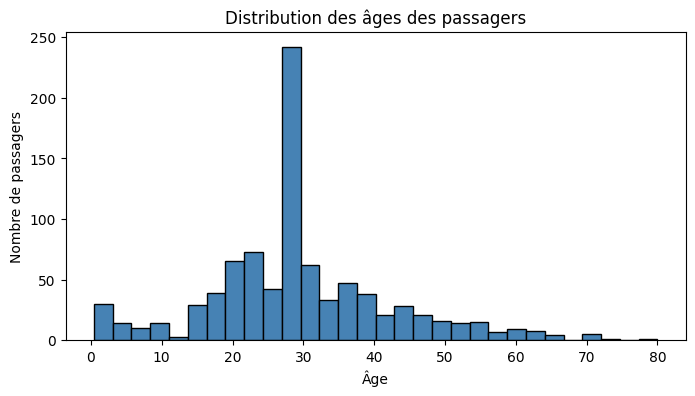

In [15]:
# 1. Histogramme des âges
plt.figure(figsize=(8, 4))
plt.hist(df['age'], bins=30, color='steelblue', edgecolor='black')
plt.title("Distribution des âges des passagers")
plt.xlabel("Âge")
plt.ylabel("Nombre de passagers")
plt.show()

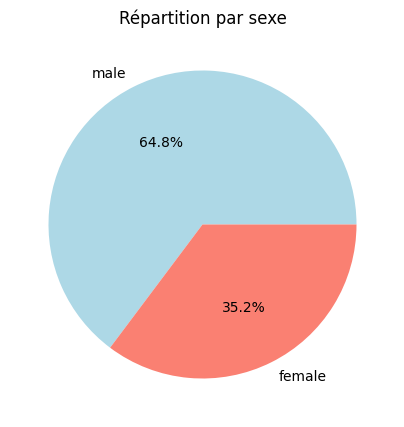

In [16]:
# 2. Diagramme circulaire - répartition par sexe
sex_counts = df['sex'].value_counts()
plt.figure(figsize=(5, 5))
plt.pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%', colors=['lightblue', 'salmon'])
plt.title("Répartition par sexe")
plt.show()

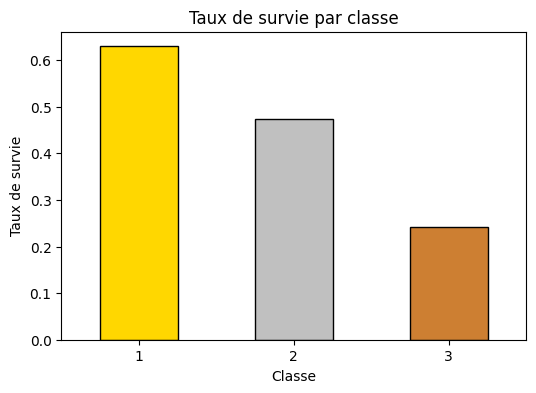

In [17]:
# 3. Taux de survie par classe
survival_by_class = df.groupby('pclass')['survived'].mean()
plt.figure(figsize=(6, 4))
survival_by_class.plot(kind='bar', color=['gold', 'silver', '#cd7f32'], edgecolor='black')
plt.title("Taux de survie par classe")
plt.xlabel("Classe")
plt.ylabel("Taux de survie")
plt.xticks(rotation=0)
plt.show()

Questions de réflexion 🤔
Problemes de qualite de donnees dectectes :

1. Problèmes de qualité détectés
Valeurs manquantes
C'est le problème principal du dataset. On a trouvé :

* age → 177 valeurs manquantes sur 891 (environ 20% des passagers n'ont pas d'âge renseigné)
* deck → 688 valeurs manquantes sur 891 (plus de 75% de la colonne est vide, elle est donc inutilisable)
* embarked → 2 valeurs manquantes sur 891 (minime mais à corriger quand même)

Doublons
On a vérifié avec df.duplicated().sum(). Dans le dataset Titanic, il n'y a normalement aucun doublon, mais c'est une vérification indispensable dans tout projet data.
Colonnes mal nommées
Les colonnes sibsp et parch ont des noms peu explicites et en anglais, ce qui nuit à la lisibilité pour une analyse en français.

2. Transformations effectuées
Remplacement des valeurs manquantes

age → remplacé par la médiane plutôt que la moyenne, car la médiane est moins sensible aux valeurs extrêmes (ex: un passager très âgé)
embarked → remplacé par le port le plus fréquent (Southampton = "S"), car c'est une variable textuelle et la moyenne n'a pas de sens sur du texte

Suppression d'une colonne

deck → supprimée car avec 75% de valeurs manquantes, elle n'apporte aucune information fiable pour l'analyse

Renommage des colonnes

sibsp → Freres/Epoux pour plus de clarté
parch → Parents/Enfants pour plus de clarté

Création d'une nouvelle colonne

TailleFamille = Freres/Epoux + Parents/Enfants + 1, pour avoir une vision globale de la taille du groupe familial de chaque passager